
<h1 style="text-align: center;"><b>Домашнее задание. Решение конкурса на kaggle</b></h1>

# Первая часть. Исследование

In [4]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

## Загрузка данных (2 балла)

1) Посмотрите на случайные строчки.

2) Посмотрите, есть ли в датасете незаполненные значения (nan'ы) с помощью data.isna() или data.info() и, если нужно, замените их на что-то. Будет хорошо, если вы построите табличку с количеством nan в каждой колонке.

In [5]:
!gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv
!gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv
!gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv

Downloading...
From: https://drive.google.com/uc?id=1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K
To: /content/train.csv
100% 664k/664k [00:00<00:00, 7.18MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r
To: /content/test.csv
100% 218k/218k [00:00<00:00, 4.69MB/s]
Downloading...
From: https://drive.google.com/uc?id=199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y
To: /content/submission.csv
100% 14.7k/14.7k [00:00<00:00, 51.5MB/s]


In [6]:
data = pd.read_csv('./train.csv')

Смотрим на первые 5 строчек в таблице

In [15]:
data.head()

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,1026.35,Male,No,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
1,72,25.85,1872.20,Male,No,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
2,1,75.90,75.90,Male,No,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,1
3,32,79.30,2570.00,Female,Yes,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check,0
4,60,115.25,6758.45,Female,No,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),0


In [7]:
# Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

# Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

С первого взгляда может показаться, что нулевых значений НаН нет, но это ошибочно.

In [8]:
# незаполненные значения (nan'ы)
data.isna().sum()

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,0
Sex,0
IsSeniorCitizen,0
HasPartner,0
HasChild,0
HasPhoneService,0
HasMultiplePhoneNumbers,0
HasInternetService,0


Видим, что колонка TotalSpent - object type. А должна быть numeric. Сделаем маску, чтобы найти значения, которые не являются числами. Таких значений всего 9, заменим их медианой.

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

In [10]:
data['TotalSpent'].value_counts().head(10)


,count
TotalSpent,
,9
20.2,9
19.75,8
19.65,6
20.05,6
19.9,5
19.45,4
50.15,4
45.3,4


In [11]:
mask = pd.to_numeric(data['TotalSpent'], errors='coerce').isna()
data.loc[mask, 'TotalSpent']
print('Number of non-numeric values: ', mask.sum())

Number of non-numeric values:  9


In [12]:
data['TotalSpent'] = pd.to_numeric(data['TotalSpent'], errors='coerce')
median_val = data['TotalSpent'].median()

# Заменяем NaN на медиану
data['TotalSpent'] = data['TotalSpent'].fillna(median_val)


In [13]:
data.describe()

,ClientPeriod,MonthlySpending,TotalSpent,IsSeniorCitizen,Churn
count,5282.000000,5282.000000,5282.000000,5282.000000,5282.000000
mean,32.397009,64.924754,2289.889086,0.159409,0.262022
std,24.550326,30.176464,2267.371263,0.366092,0.439776
min,0.000000,18.250000,18.800000,0.000000,0.000000
25%,9.000000,35.462500,401.587500,0.000000,0.000000
50%,29.000000,70.400000,1410.250000,0.000000,0.000000
75%,55.000000,90.050000,3795.212500,0.000000,1.000000
max,72.000000,118.750000,8684.800000,1.000000,1.000000


Переведем IsSeniorCitizen в катгориальные признаки для удобства визуализации вместе с остальными категориальными признаками. Заодно отметим, что примерно 16% клиентов пожилых клиентов.

In [14]:
data['IsSeniorCitizen'] = data['IsSeniorCitizen'].map({1: 'Yes', 0: 'No'})


Как мы видим, теперь все строчки заполнены, приступаем к exploratory data analysis (EDA).

## Анализ данных (3 балла)

1) Для численных призанков постройте гистограмму (*plt.hist(...)*) или boxplot (*plt.boxplot(...)*). Для категориальных посчитайте количество каждого значения для каждого признака. Для каждой колонки надо сделать *data.value_counts()* и построить bar диаграммы *plt.bar(...)* или круговые диаграммы *plt.pie(...)* (хорошо, елси вы сможете это сделать на одном гарфике с помощью *plt.subplots(...)*).

2) Посмотрите на распределение целевой переменной и скажите, являются ли классы несбалансированными.

3) (Если будет желание) Поиграйте с разными библиотеками для визуализации - *sns*, *pandas_visual_analysis*, etc.

Второй пункт очень важен, потому что существуют задачи классификации с несбалансированными классами. Например, это может значить, что в датасете намного больше примеров 0 класса. В таких случаях нужно 1) не использовать accuracy как метрику 2) использовать методы борьбы с imbalanced dataset (обычно если датасет сильно несбалансирован, т.е. класса 1 в 20 раз меньше класса 0).

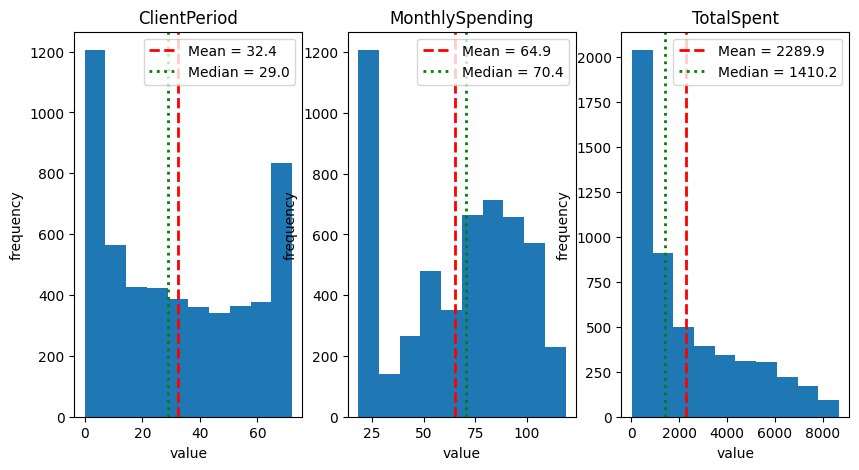

In [16]:
import matplotlib.pyplot as plt
# гистограмма для численных признаков
fig, axes = plt.subplots(1,3, figsize=(10,5))

for i, col in enumerate(num_cols):
  axes[i].hist(data[col])

# Среднее и медиана
  mean_val = data[col].mean()
  median_val = data[col].median()

# Вертикальные линии
  axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.1f}')
  axes[i].axvline(median_val, color='green', linestyle=':', linewidth=2, label=f'Median = {median_val:.1f}')
  axes[i].legend()
  axes[i].set_title(col)
  axes[i].set_xlabel('value')
  axes[i].set_ylabel('frequency')
plt.show()

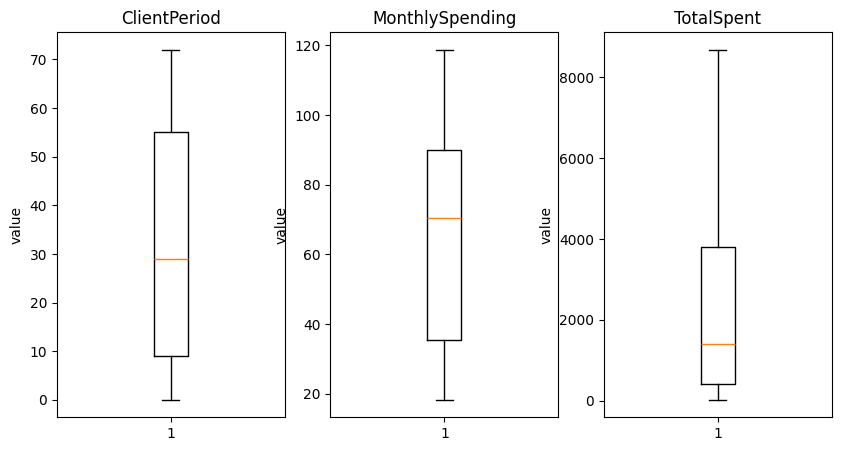

In [17]:
# boxplot для числовых признаков
fig, axes = plt.subplots(1,3, figsize=(10,5))

for i, col in enumerate(num_cols):
  axes[i].boxplot(data[col])
  axes[i].set_title(col)
  axes[i].set_ylabel('value')
plt.show()

Покажем значения для каждого категориального признака в процентах. Построим диаграммы plt.bar(...) и круговые диаграммы plt.pie(...) с помощью plt.subplots(...)).

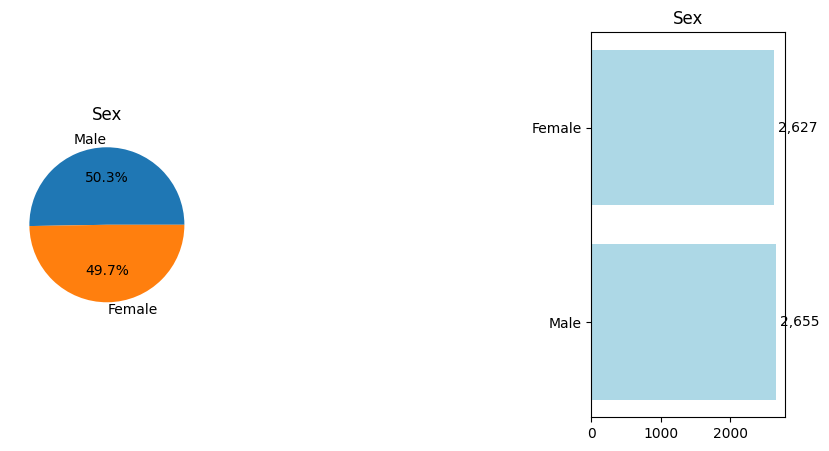

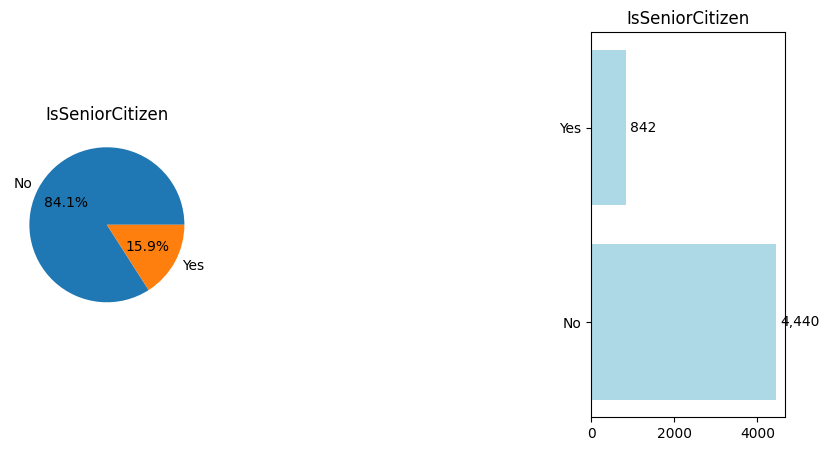

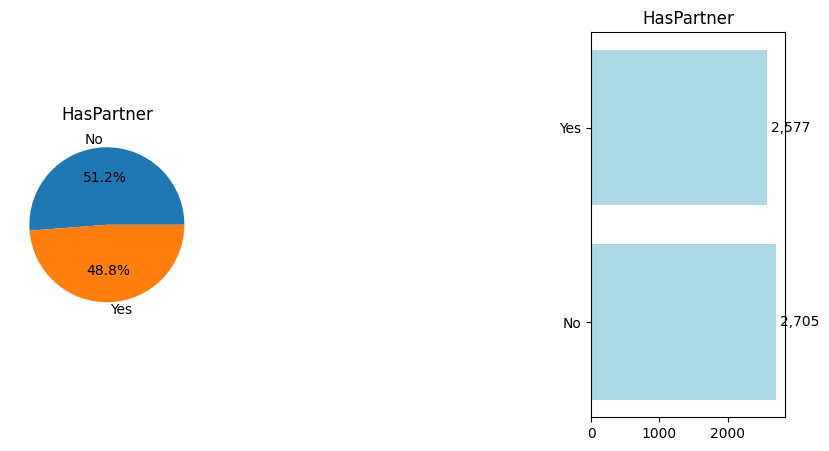

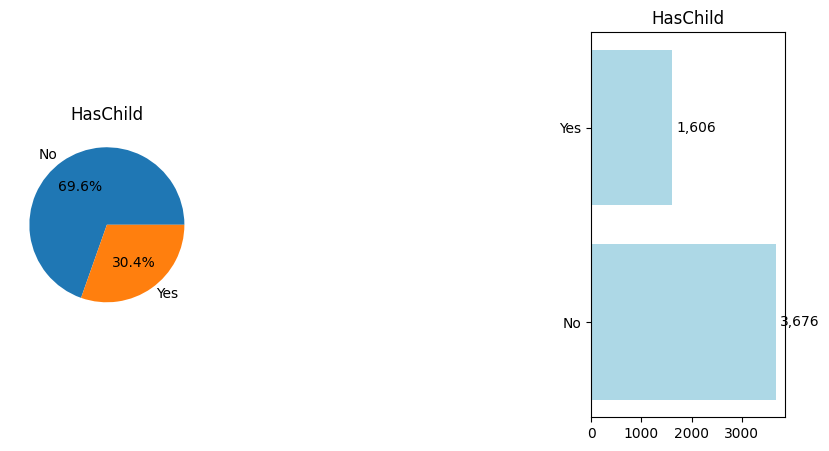

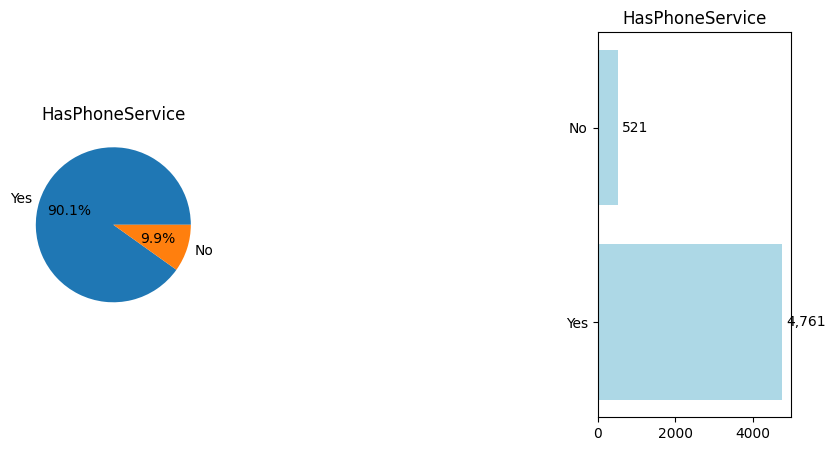

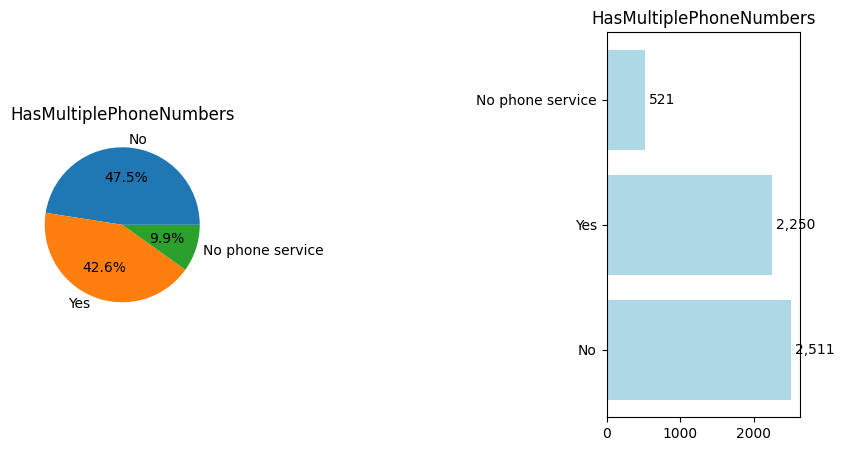

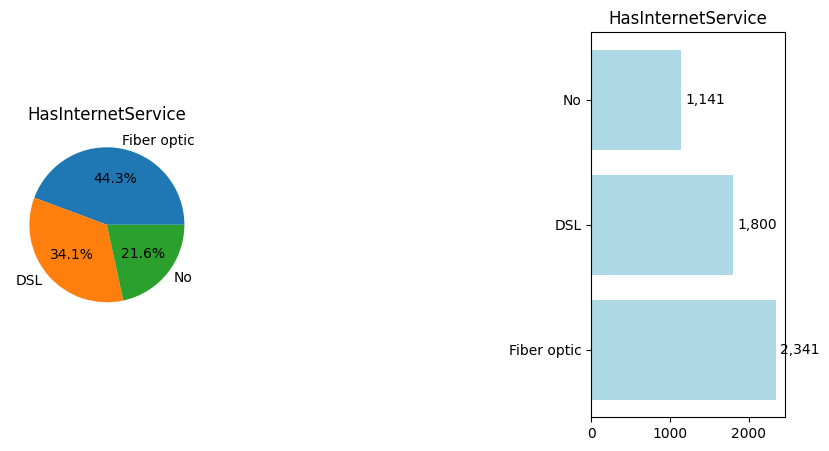

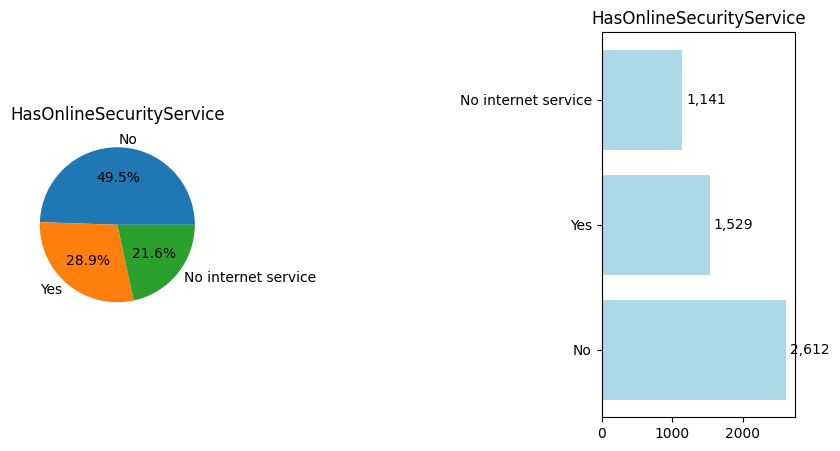

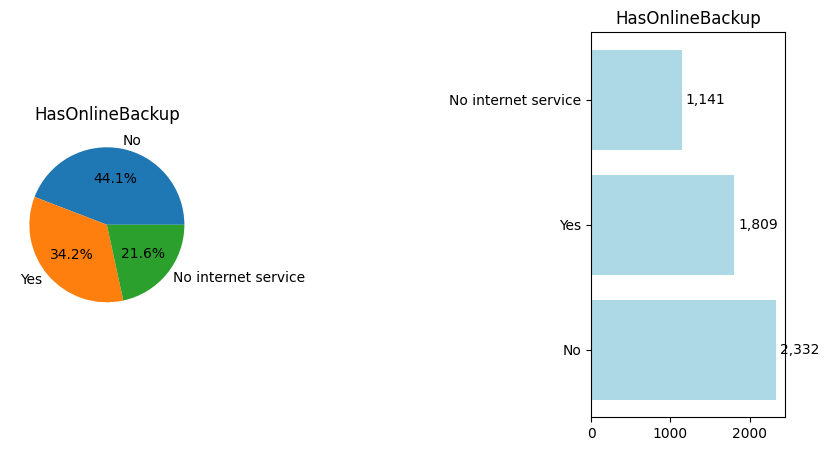

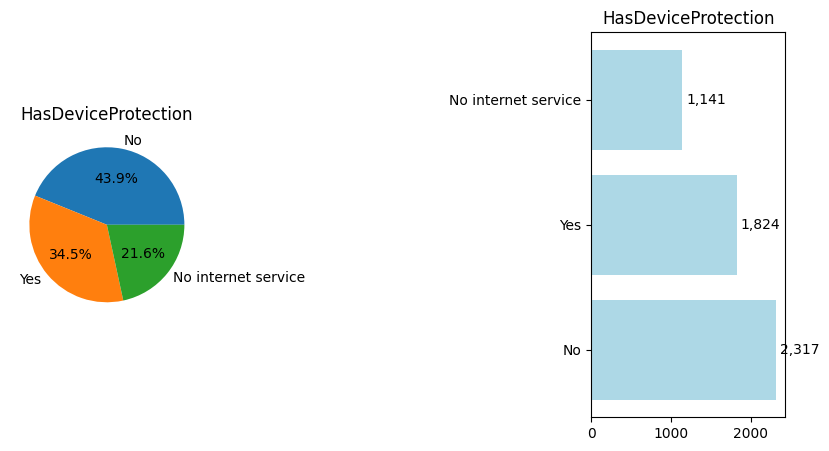

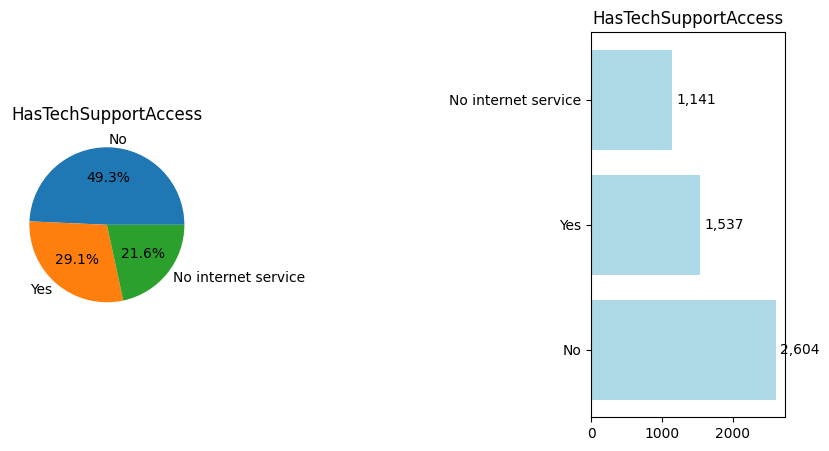

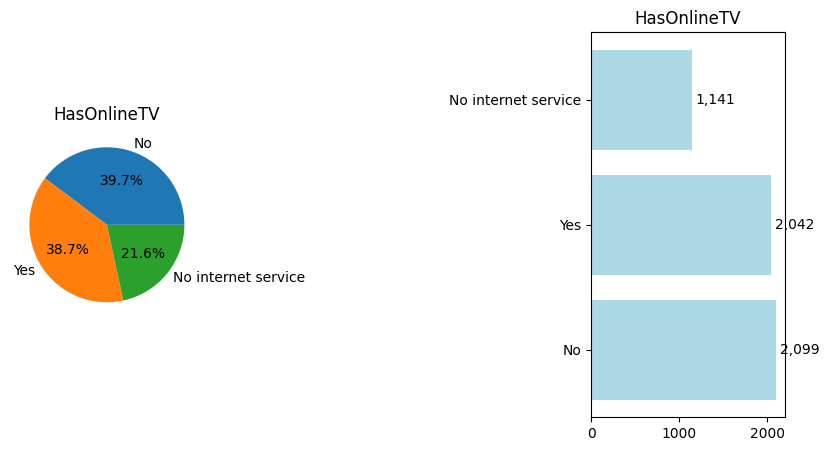

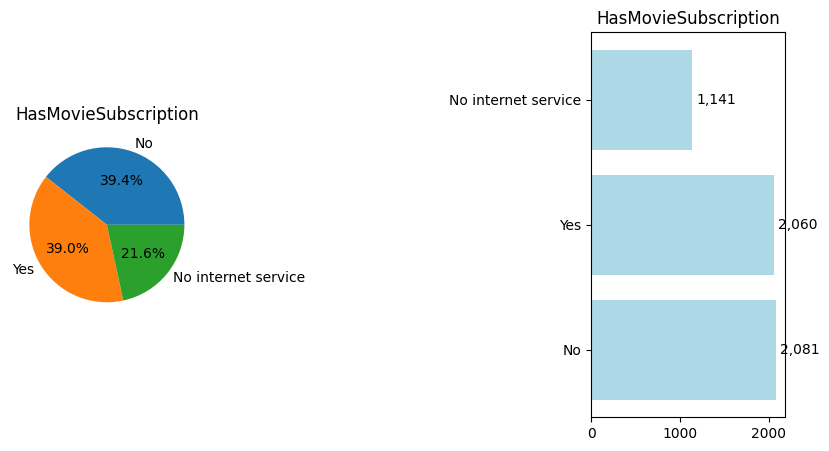

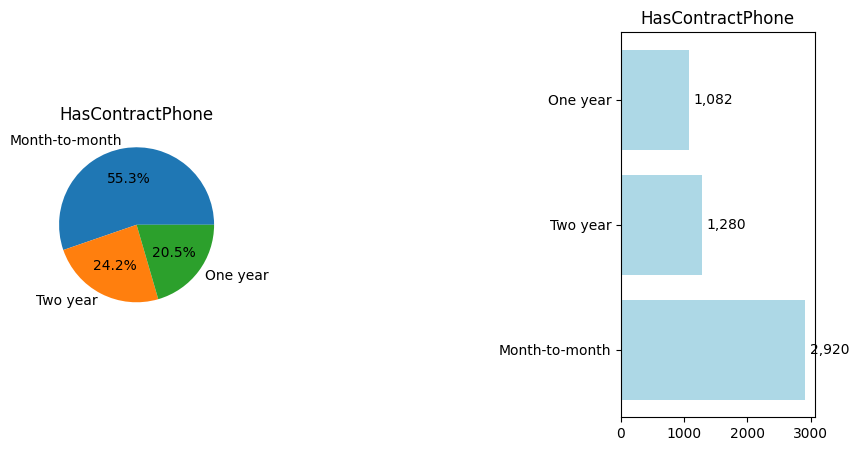

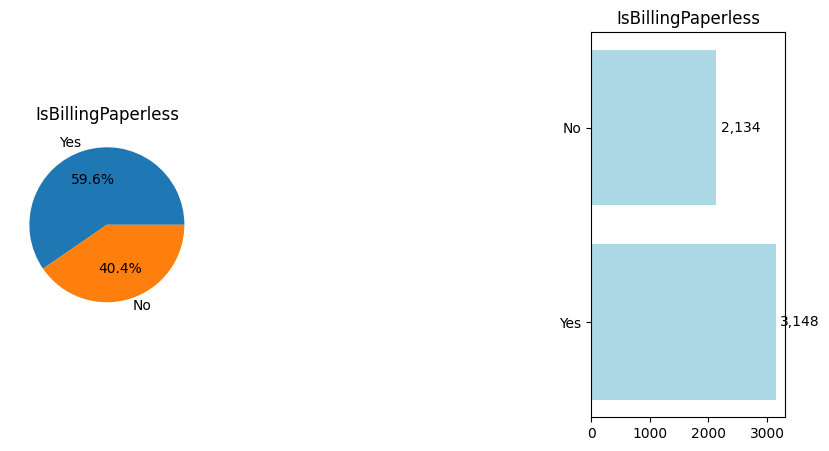

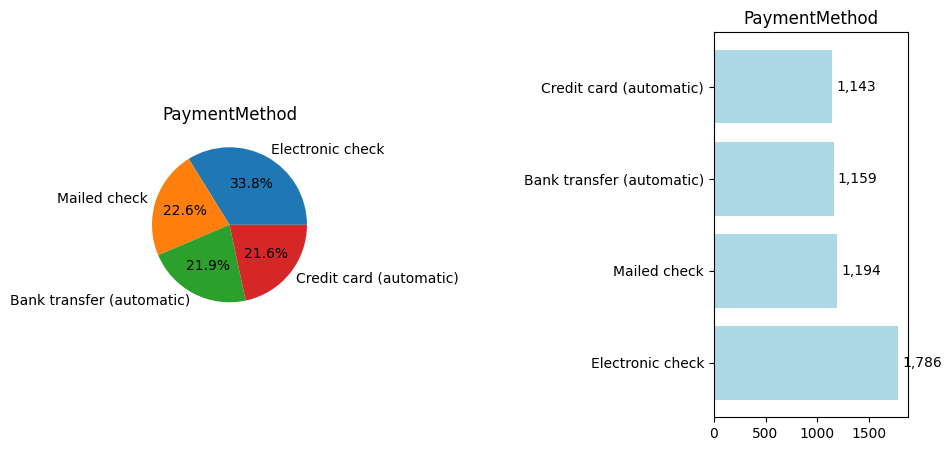

In [18]:
for col in cat_cols:
  fig, axes = plt.subplots(1,2, figsize=(10,5))
  plt.subplots_adjust(wspace=2.0)
  axes[0].pie(data[col].value_counts(), labels=data[col].value_counts().index, autopct='%1.1f%%')
  axes[0].set_title(col)
  bars = axes[1].barh(data[col].value_counts().index, data[col].value_counts(), color='lightblue')
  axes[1].bar_label(bars, labels=[f'{v:,}' for v in data[col].value_counts().values], padding=3)
  axes[1].set_title(col)
  plt.show()

В датасете намного больше примеров 0 класса. **Классы** **являются несбалансированными** в соотношении 1 к 3. На каждого отключившегося клиента приходится три оставшихся с компанией. Учтем это при обучении моделей, проводя **стратификацию**.  

In [19]:
y = data[target_col]
y.value_counts()

,count
Churn,
0,3898
1,1384


(Если будет желание) Поиграйте с разными библиотеками для визуализации - sns, pandas_visual_analysis, etc. KDE гистограмма добавляет плавную линию плотности, показывая форму распределения. Просто добавляю как визуальный пример того, что можно показать на численных колонках.

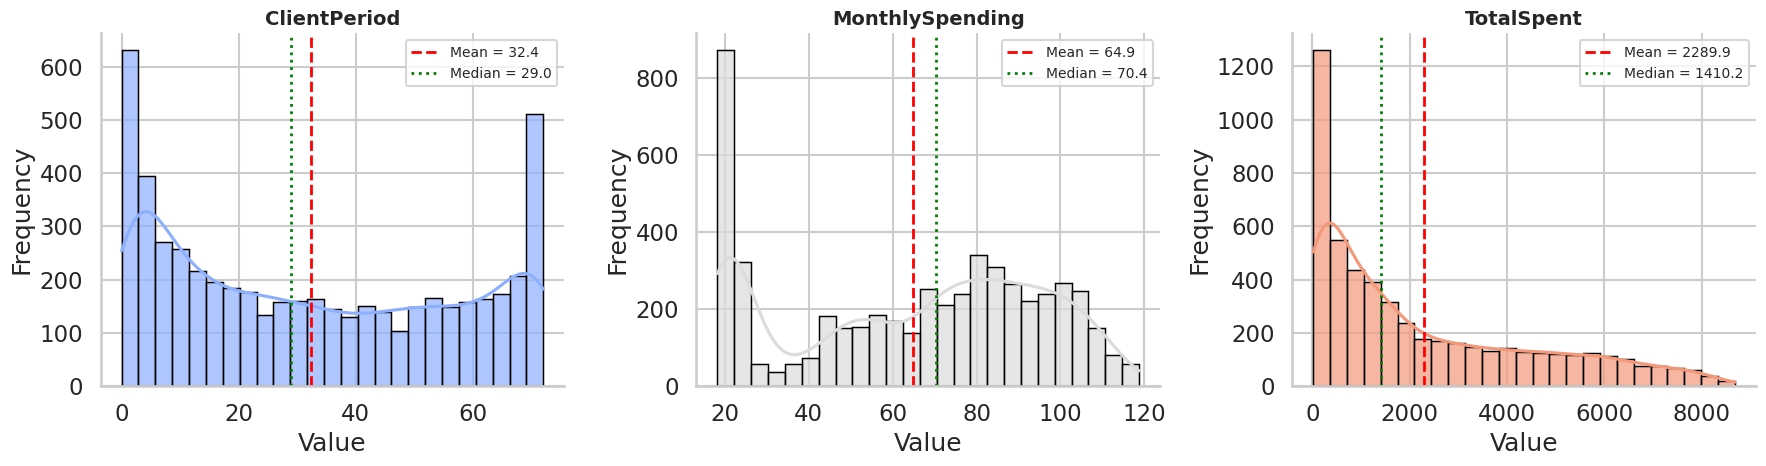

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


sns.set(style='whitegrid', context='talk', palette='coolwarm')

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 5))

for i, col in enumerate(num_cols):
    ax = axes[i]

    # KDE-гистограмма
    sns.histplot(
        data[col],
        bins=25,
        kde=True,
        color=sns.color_palette('coolwarm', len(num_cols))[i],
        edgecolor='black',
        alpha=0.7,
        ax=ax
    )


    mean_val = data[col].mean()
    median_val = data[col].median()

    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.1f}')
    ax.axvline(median_val, color='green', linestyle=':', linewidth=2, label=f'Median = {median_val:.1f}')


    ax.set_title(f'{col}', fontsize=14, weight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=10)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()


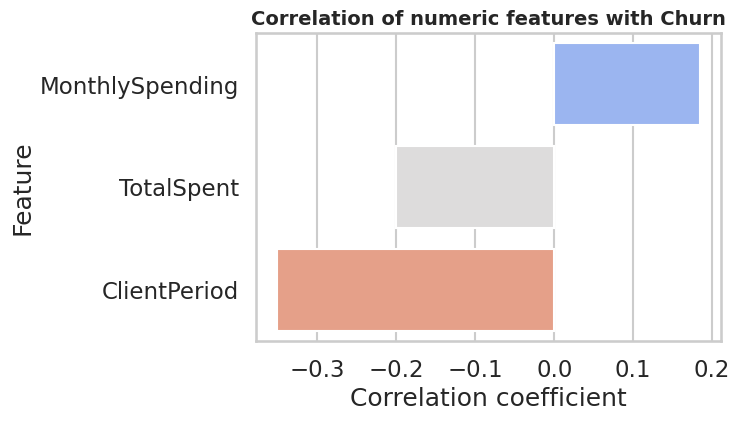

In [21]:
corr_with_target = (
    data[num_cols + [target_col]]
    .corr()[target_col]
    .drop(target_col)       # <--- убираем сам Churn
    .sort_values(ascending=False)
)

plt.figure(figsize=(6,4))
sns.barplot(
    x=corr_with_target.values,
    y=corr_with_target.index,
    hue=corr_with_target.index,
    palette='coolwarm'
)
plt.title(f'Correlation of numeric features with {target_col}', fontsize=14, weight='bold')
plt.xlabel('Correlation coefficient')
plt.ylabel('Feature')
plt.show()


Как видим, чем больше клиент провел времени с компанией, тем менее вероятен его уход от нее. 'TotalSpent' - слабая отрицательная корреляция - значит, общие траты почти не влияют на факт ухода. Клиенты с более высокими ежемесячными расходами немного чаще уходят. Категориальные признаки в матрицу корреляций не включаем, но в принципе в конце работы, когда визуализируем feature importances, то будет видно, на какие признаки модель опиралась больше всего. Выкидывать какие-то признаки для бустинга я не стала.

## Применение линейных моделей (3 балла)

1) Обработайте данные для того, чтобы к ним можно было применить LogisticRegression. Т.е. отнормируйте числовые признаки, а категориальные закодируйте с помощью one-hot-encoding'а.

2) С помощью кроссвалидации или разделения на train/valid выборку протестируйте разные значения гиперпараметра C и выберите лучший (можно тестировать С=100, 10, 1, 0.1, 0.01, 0.001) по метрике ROC-AUC.

Если вы разделяете на train/valid, то используйте LogisticRegressionCV. Он сам при вызове .fit() подберет параметр С. (не забудьте передать scroing='roc_auc', чтобы при кроссвалидации сравнивались значения этой метрики, и refit=True, чтобы при потом модель обучилась на всем датасете с лучшим параметром C).


(более сложный вариант) Если вы будете использовать кроссвалидацию, то преобразования данных и LogisticRegression нужно соединить в один Pipeline с помощью make_pipeline, как это делалось во втором семинаре. Потом pipeline надо передать в GridSearchCV. Для one-hot-encoding'a можно испльзовать комбинацию LabelEncoder + OneHotEncoder (сначала превращаем строчки в числа, а потом числа првращаем в one-hot вектора.)

In [22]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline

создадим два пайплайна - один для числовых, другой для категориальных признаков. В первом применим нормировку, во втором ohe. обьединим в один трансформер колонок, который будет нашим preprocessor.

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

Если вы будете использовать кроссвалидацию, то преобразования данных и LogisticRegression нужно соединить в один Pipeline с помощью make_pipeline, как это делалось во втором семинаре. Потом pipeline надо передать в GridSearchCV. Для one-hot-encoding'a можно испльзовать комбинацию LabelEncoder + OneHotEncoder (сначала превращаем строчки в числа, а потом числа првращаем в one-hot вектора.)

In [24]:
X = data.drop(target_col, axis=1)
y = data[target_col]

In [25]:
pipeline = make_pipeline(
    preprocessor,
    LogisticRegression()
)
parameters = {
    'logisticregression__C': [100, 10, 1, 0.1, 0.01, 0.001],
}
clf = GridSearchCV(pipeline, parameters, scoring='roc_auc', cv=5)
clf.fit(X, y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['ClientPeriod',
                                                                          'MonthlySpending',
                                                                          'TotalSpent']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Sex',
                                                                          'IsSeniorCitizen',
                                                                          'HasPartner',
                                                                          'HasChild',
                                                                          'HasPhoneService',
                                                                          'HasMult...PhoneNumbers',
                                                                          'HasInternetService',
                                                                          'HasOnlineSecurityService',
                                                                          'HasOnlineBackup',
                                                                          'HasDeviceProtection',
                                                                          'HasTechSupportAccess',
                                                                          'HasOnlineTV',
                                                                          'HasMovieSubscription',
                                                                          'HasContractPhone',
                                                                          'IsBillingPaperless',
                                                                          'PaymentMethod'])])),
                                       ('logisticregression',
                                        LogisticRegression())]),
             param_grid={'logisticregression__C': [100, 10, 1, 0.1, 0.01,
                                                   0.001]},
             scoring='roc_auc')

Выпишите какое лучшее качество и с какими параметрами вам удалось получить

In [26]:
print("Лучшие параметры:", clf.best_params_)
print("Лучший ROC-AUC:", clf.best_score_)

Лучшие параметры: {'logisticregression__C': 10}
Лучший ROC-AUC: 0.8450324270643002


## Применение градиентного бустинга (2 балла)

Если вы хотите получить баллы за точный ответ, то стоит попробовать градиентный бустинг. Часто градиентный бустинг с параметрами по умолчанию даст вам 80% результата за 0% усилий.

Мы будем использовать catboost, поэтому нам не надо кодировать категориальные признаки. Catboost сделает это сам (в .fit() надо передать cat_features=cat_cols). А численные признаки нормировать для моделей, основанных на деревьях не нужно.

1) Разделите выборку на train/valid. Протестируйте catboost cо стандартными параметрами.

2) Протестируйте разные занчения параметров количества деревьев и learning_rate'а и выберите лучшую по метрике ROC-AUC комбинацию.

(Дополнительно) Есть некоторые сложности с тем, чтобы использовать CatBoostClassifier вместе с GridSearchCV, поэтому мы не просим использовать кроссвалидацию. Но можете попробовать)

In [27]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.4 MB/s eta 0:00:00


Сетку параметров оставим небольшую, чтобы не занимать много времени на обучение модели. При желании увеличить качество модели потребуется только увеличить количество значений для перебора.

In [29]:
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier
model = CatBoostClassifier(
    iterations=300,
    cat_features=cat_cols,
    verbose=False,
    task_type='GPU',
    devices='0',
    early_stopping_rounds=50,
)

param_grid = {
    'learning_rate': [0.01, 0.1],
    'depth': [4, 6]
}

grid = GridSearchCV(model, param_grid, scoring='roc_auc', cv=3)
grid.fit(X, y)

print(grid.best_params_, grid.best_score_)


{'depth': 4, 'learning_rate': 0.01} 0.8445577658386694


In [39]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = CatBoostClassifier(
    iterations=1000,
    cat_features=cat_cols,
    verbose=False
)
model.fit(X_train, y_train)

best_params = grid.best_params_
model = CatBoostClassifier(
    **best_params,
    iterations=1000,
    cat_features=cat_cols,
    verbose=False
)
model.fit(X_train, y_train)

feat_imp = model.get_feature_importance(prettified=True)
print(feat_imp)

score = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
print(f'ROC-AUC: {score}')



                  Feature Id  Importances
0           HasContractPhone    30.625497
1               ClientPeriod    15.063573
2         HasInternetService     9.070510
3            MonthlySpending     8.333737
4   HasOnlineSecurityService     6.985305
5                 TotalSpent     6.282572
6              PaymentMethod     5.037127
7       HasTechSupportAccess     3.656673
8    HasMultiplePhoneNumbers     3.627529
9         IsBillingPaperless     2.651697
10           HasOnlineBackup     2.531964
11           IsSeniorCitizen     1.733230
12      HasMovieSubscription     1.242027
13               HasOnlineTV     1.184175
14       HasDeviceProtection     0.920135
15                       Sex     0.911410
16                HasPartner     0.051023
17           HasPhoneService     0.047378
18                  HasChild     0.044439
ROC-AUC: 0.8561047857076738


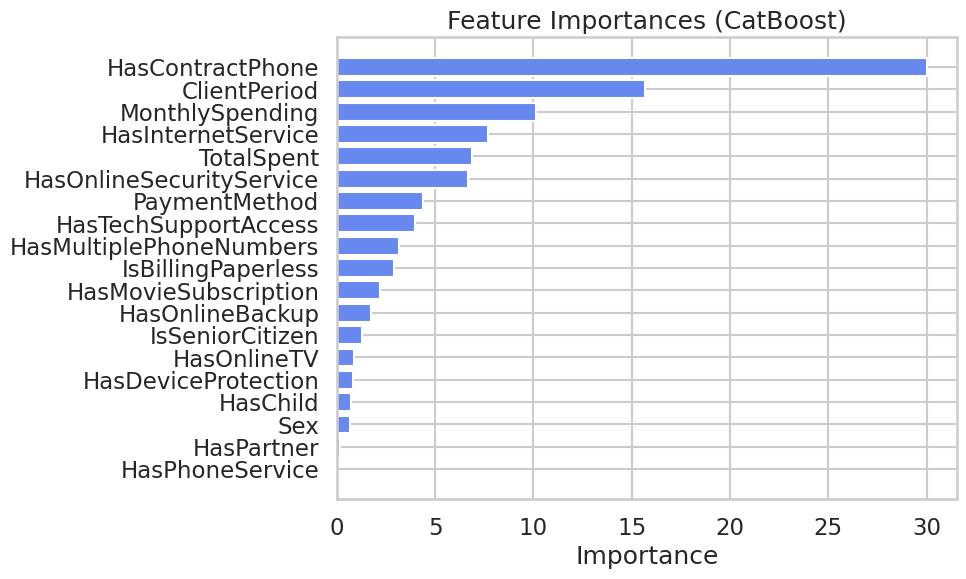

In [36]:
import matplotlib.pyplot as plt

feat_imp = model.get_feature_importance(prettified=True)
plt.figure(figsize=(8,6))
plt.barh(feat_imp['Feature Id'], feat_imp['Importances'])
plt.gca().invert_yaxis()
plt.title('Feature Importances (CatBoost)')
plt.xlabel('Importance')
plt.show()


Модель оценила, какие признаки сильнее всего влияют на прогноз оттока (churn). Пол, наличие партнера и ребенка и базовый телефон мало что решают. Напротив, наличие контракта - ключевой индикатор, как и длительность ползования (клиентский период), чем дольше клиент остается, тем меньше шанс оттока.

Выпишите, какое лучшее качество и с какими параметрами вам удалось получить

CatBoost

ROC-AUC: 0.8561047857076738
{'depth': 4, 'learning_rate': 0.01}

# Предсказания

Поскольку выбираем только лучшую модель для предсказания, игнорируем LogReg и пайплайны, примененнные на трейне. CatBoost не требует препроцессинга данных, занимаясь этим самостоятельно.

In [40]:
X_test = pd.read_csv('./test.csv')
submission = pd.read_csv('./submission.csv')

In [42]:
best_model = model
y_test_pred = best_model.predict_proba(X_test)
y_test_pred

array([[0.95620827, 0.04379173],
       [0.40095036, 0.59904964],
       [0.35090039, 0.64909961],
       ...,
       [0.16625514, 0.83374486],
       [0.44692605, 0.55307395],
       [0.98357664, 0.01642336]])

In [43]:
submission = pd.read_csv('./submission.csv')
submission['Churn'] = y_test_pred[:,1]   # именно вероятности класса 1
submission.to_csv('./my_submission.csv', index=False)


Лучшее решение отправьте в Stepik. (Kaggle score на тесте получился 0.85104)